# Laboratorium 7:

In [2]:
import pymc as pm
import arviz as az
import numpy as np

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


In [3]:
survey_num = 100

def count_prob(yes_count):
    with pm.Model() as model:
        p_d = pm.Uniform('p_d', lower=0, upper=1)
        occurrences = np.array([1]*yes_count + [0]*(survey_num - yes_count))

        p_observed = pm.Deterministic("p_observed", 0.25 + 0.5*p_d)
        
        # answers = pm.Bernoulli("answers", p_observed, observed=occurrences)
        answers = pm.Binomial("answers", survey_num, p_observed, observed=yes_count)

        trace = pm.sample(2000, tune=1000, return_inferencedata=True, cores=1)
        
        summary = az.summary(trace, var_names=["p_d", "p_observed"])
        print(summary)
        
        az.plot_trace(trace, var_names=["p_d", "p_observed"], show=True)

### 10 odpowiedzi TAK:

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [p_d]
Sequential sampling (2 chains in 1 job)
NUTS: [p_d]


Output()

Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 20 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
We recommend running at least 4 chains for robust computation of convergence diagnostics


             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
p_d         0.024  0.022    0.00    0.064      0.001    0.001     936.0   
p_observed  0.262  0.011    0.25    0.282      0.000    0.000     936.0   

            ess_tail  r_hat  
p_d           1081.0    1.0  
p_observed    1081.0    1.0  


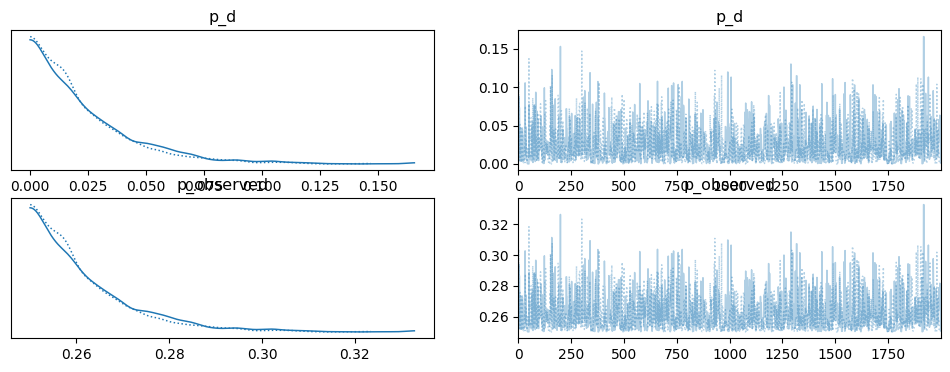

In [4]:
count_prob(10)

### 20 odpowiedzi TAK:

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [p_d]
Sequential sampling (2 chains in 1 job)
NUTS: [p_d]


Output()

Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 20 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
We recommend running at least 4 chains for robust computation of convergence diagnostics


             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
p_d         0.045  0.039    0.00    0.116      0.001    0.001    1038.0   
p_observed  0.273  0.019    0.25    0.308      0.001    0.000    1038.0   

            ess_tail  r_hat  
p_d           1029.0    1.0  
p_observed    1029.0    1.0  


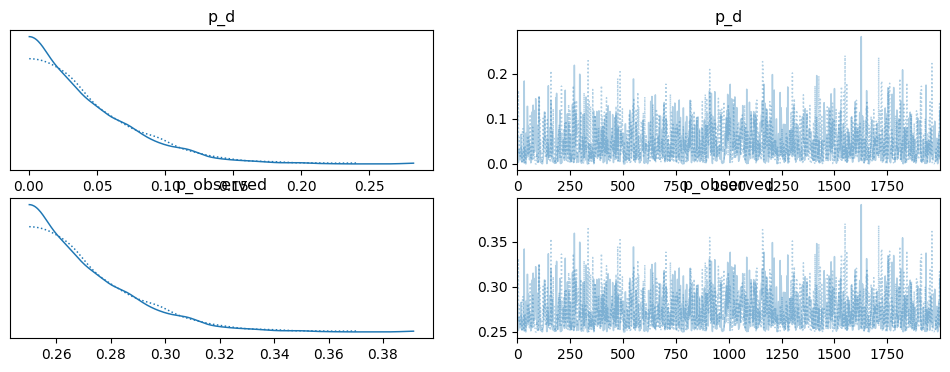

In [5]:
count_prob(20)

### 5 odpowiedzi TAK:

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [p_d]
Sequential sampling (2 chains in 1 job)
NUTS: [p_d]


Output()

Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 20 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
We recommend running at least 4 chains for robust computation of convergence diagnostics


             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
p_d         0.017  0.018    0.00    0.048        0.0    0.001     883.0   
p_observed  0.259  0.009    0.25    0.274        0.0    0.000     883.0   

            ess_tail  r_hat  
p_d            744.0    1.0  
p_observed     744.0    1.0  


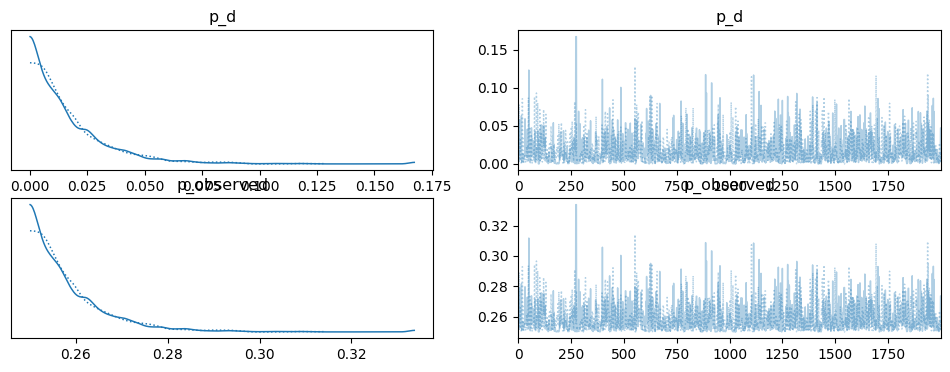

In [6]:
count_prob(5)

### Wnioski:

Wyniki p_d przyjmują bardzo niskie wartości:
* **5%**:  **P_D:** 0.018 (1,8%) | **P_OBSERVED:** 0.259 (25,9%)
* **10%**: **P_D:** 0.023 (2,3%) | **P_OBSERVED:** 0.262 (26,2%)
* **20%**: **P_D:** 0.047 (4,7%) | **P_OBSERVED:** 0.273 (27,3%)

Co sugeruje, że wyniki p_observed głównie wynikają z mechanizmu losowego rzutu monetą, który niezależnie od prawdopodobieństwa p_d gwarantuje zawsze minimum 25% odpowiedzi "tak". 

# Laboratorium 8:

Generowanie 100 odpowiedzi dla różnych prawdopodobieństw:

In [7]:
def generate_data(p_d, survey_size=100):
    p_observed = 0.25 + 0.5 * p_d
    
    with pm.Model() as generative_model:
        answers_dist = pm.Binomial('answers', n=1, p=p_observed, shape=survey_size)
        
        prior_samples = pm.sample_prior_predictive(samples=1, random_seed=42)
    
    answers = prior_samples.prior['answers'].values[0, 0, :]
    yes_count = int(np.sum(answers))
    
    return answers, yes_count

probabilities = [0.1, 0.5, 0.9]
results = {}

for p_d in probabilities:
    answers, yes_count = generate_data(p_d, survey_size=100)
    print("Generowane odpowiedzi:", answers)
    results[p_d] = {
        'answers': answers,
        'yes_count': yes_count,
        'p_observed': 0.25 + 0.5 * p_d
    }
    print(f"p_d = {p_d}:")
    print(f"  p_observed ze wzoru: {results[p_d]['p_observed']:.2f}")
    print(f"  Liczba odpowiedzi TAK: {yes_count}/100 ({yes_count}%)")
    print(f"  p_observed na podstawie losowo generowanych odpowiedzi: {yes_count/100:.2f}")
    print()

Sampling: [answers]
Sampling: [answers]
Sampling: [answers]
Sampling: [answers]
Sampling: [answers]


Generowane odpowiedzi: [1 1 1 0 1 0 1 1 0 0 0 0 0 1 0 0 1 0 1 0 0 0 1 1 0 0 0 0 1 1 0 0 0 0 1 0 0
 1 0 0 0 1 0 0 1 1 0 0 0 0 0 0 0 1 1 0 1 0 1 0 1 1 0 0 1 0 0 0 0 0 0 0 0 0
 0 0 0 1 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0]
p_d = 0.1:
  p_observed ze wzoru: 0.30
  Liczba odpowiedzi TAK: 29/100 (29%)
  p_observed na podstawie losowo generowanych odpowiedzi: 0.29

Generowane odpowiedzi: [1 1 1 0 1 0 1 1 0 0 1 0 0 1 0 0 1 0 1 1 0 0 1 1 0 1 0 1 1 1 0 1 0 1 1 1 0
 1 1 0 0 1 1 0 1 1 0 0 0 1 1 0 0 1 1 1 1 1 1 1 1 1 1 0 1 1 1 0 0 0 0 0 0 0
 1 1 0 1 1 1 0 0 1 1 0 0 0 0 1 1 0 0 0 1 0 0 1 1 0 0]
p_d = 0.5:
  p_observed ze wzoru: 0.50
  Liczba odpowiedzi TAK: 54/100 (54%)
  p_observed na podstawie losowo generowanych odpowiedzi: 0.54

Generowane odpowiedzi: [0 0 0 1 0 1 0 0 1 1 1 1 1 0 1 1 0 1 0 1 1 1 0 0 1 1 1 1 0 0 1 1 1 1 0 1 1
 0 1 1 1 0 1 1 0 0 1 1 1 1 1 1 1 0 0 1 0 1 0 1 0 0 1 1 0 1 1 1 1 1 1 1 1 1
 1 1 1 0 1 0 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1]
p_d = 0.9:
  p_observed ze wzoru: 0.7

50 powtórzeń ankiety dla p_d = 0.1:

In [14]:
p_d = 0.1
p_observed = 0.25 + 0.5 * p_d

with pm.Model() as repeated_survey_model:
    yes_counts_dist = pm.Binomial('yes_counts', n=100, p=p_observed, shape=50)
    
    prior_samples = pm.sample_prior_predictive(samples=1, random_seed=42)

yes_counts = prior_samples.prior['yes_counts'].values[0, 0, :]
yes_counts_array = np.array(yes_counts)

print(f"Results: {yes_counts_array.astype(int).tolist()}")
print(f"Statystyki liczby odpowiedzi TAK:")
print(f"  Średnia: {np.mean(yes_counts_array):.2f}")
print(f"  Odchylenie standardowe: {np.std(yes_counts_array):.2f}")
print(f"  Mediana: {np.median(yes_counts_array):.0f}")
print(f"  Min: {np.min(yes_counts_array)}")
print(f"  Max: {np.max(yes_counts_array)}")

Sampling: [yes_counts]


Results: [36, 36, 35, 28, 38, 26, 43, 33, 25, 29, 31, 26, 27, 37, 29, 24, 37, 20, 33, 30, 25, 29, 34, 35, 23, 31, 25, 31, 33, 33, 28, 31, 24, 31, 33, 32, 21, 36, 32, 23, 26, 35, 31, 25, 33, 34, 28, 22, 24, 30]
Statystyki liczby odpowiedzi TAK:
  Średnia: 30.02
  Odchylenie standardowe: 4.97
  Mediana: 31
  Min: 20
  Max: 43
